In [15]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool, BaseTool
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI(model='gpt-4o-mini')

In [ ]:
loader = PyMuPDFLoader(r'../thebook.pdf')
docs = loader.load()


In [10]:
len(docs)

234

In [13]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [14]:
len(chunks)

552

In [17]:
embedder = OpenAIEmbeddings(model = 'text-embedding-3-small')
vector_sotre = FAISS.from_documents(chunks, embedder)

In [18]:
vector_sotre

In [19]:
retriever = vector_sotre.as_retriever(search_type = 'similarity', search_kwargs={'k': 4})

In [20]:
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [docs.page_content for docs in result]
    metadata = [docs.metadata for docs in result]

    return {
        'query': query, 
        'context': context, 
        'metadata': metadata
    }

In [25]:
rag_tool.invoke('what is decision tree')

{'query': 'what is decision tree',
 'context': ['INTRODUCTION TO MACHINE LEARNING',
  'our discussion will largely focus on a choice set of such problems. We now\ngive a by no means complete list of templates.\nBinary Classiﬁcation is probably the most frequently studied problem\nin machine learning and it has led to a large number of important algorithmic\nand theoretic developments over the past century. In its simplest form it\nreduces to the question: given a pattern x drawn from a domain X, estimate\nwhich value an associated binary random variable y ∈{±1} will assume.\nFor instance, given pictures of apples and oranges, we might want to state\nwhether the object in question is an apple or an orange. Equally well, we\nmight want to predict whether a home owner might default on his loan,\ngiven income data, his credit history, or whether a given e-mail is spam or\nham. The ability to solve this basic problem already allows us to address a\nlarge variety of practical settings.\nTher

In [26]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [27]:
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]
    

In [28]:
def chat_node(state: ChatState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [29]:
tool_node = ToolNode(tools)

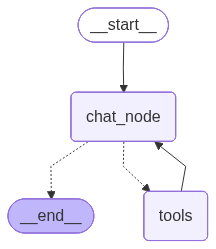

In [31]:
graph = StateGraph(ChatState)

graph.add_node( 'chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()
chatbot


In [34]:
result = chatbot.invoke(
    {
        'messages': [
            HumanMessage(
                content=(
                    'Using the pdf notes, explain how to split a node in a decision tree'
                )
            )
        ]
    }
)
result['messages'][-1].content

'The notes do not provide a direct explanation on how to split a node in a decision tree specifically, but they mention related concepts in decision tree structures. Here’s a general process for splitting a node in a decision tree based on common practices in machine learning:\n\n1. **Choose the Best Attribute**: For a given node, evaluate all possible attributes that can be used for splitting the data. The goal is to select the attribute that provides the most information gain or the most significant reduction in impurity (e.g., Gini impurity or entropy).\n\n2. **Calculate Impurity**: For each attribute, calculate the impurity of the current node and the expected impurity after splitting. This typically involves calculating metrics like entropy or Gini impurity.\n\n3. **Perform the Split**: Based on the attribute selected, divide the data into two or more groups. Each group represents a branch of the tree based on the values of the chosen attribute.\n\n4. **Create Child Nodes**: Each 

In [35]:
print(result['messages'][-1].content)

The notes do not provide a direct explanation on how to split a node in a decision tree specifically, but they mention related concepts in decision tree structures. Here’s a general process for splitting a node in a decision tree based on common practices in machine learning:

1. **Choose the Best Attribute**: For a given node, evaluate all possible attributes that can be used for splitting the data. The goal is to select the attribute that provides the most information gain or the most significant reduction in impurity (e.g., Gini impurity or entropy).

2. **Calculate Impurity**: For each attribute, calculate the impurity of the current node and the expected impurity after splitting. This typically involves calculating metrics like entropy or Gini impurity.

3. **Perform the Split**: Based on the attribute selected, divide the data into two or more groups. Each group represents a branch of the tree based on the values of the chosen attribute.

4. **Create Child Nodes**: Each split cre